In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
df=pd.read_csv("/content/zomato.csv", on_bad_lines='skip',engine='python')
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51151,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51152,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51153,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23036 entries, 0 to 23035
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          23036 non-null  object
 1   address                      23036 non-null  object
 2   name                         23036 non-null  object
 3   online_order                 23036 non-null  object
 4   book_table                   23036 non-null  object
 5   rate                         19598 non-null  object
 6   votes                        23036 non-null  int64 
 7   phone                        22576 non-null  object
 8   location                     23032 non-null  object
 9   rest_type                    22942 non-null  object
 10  dish_liked                   10249 non-null  object
 11  cuisines                     23021 non-null  object
 12  approx_cost(for two people)  22959 non-null  object
 13  reviews_list                 23

In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,3438
votes,0
phone,460
location,4
rest_type,94


In [ ]:
df.shape

(23036, 17)

In [ ]:
zomato=df.drop(['url','phone','dish_liked'],axis=1)
zomato

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51151,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,[],[],Pubs and bars,Whitefield
51152,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51153,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
zomato.isnull().sum()

,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,224
cuisines,45
approx_cost(for two people),344


**REMOVING DUPLICATES**

In [ ]:
zomato.duplicated().sum()
zomato.drop_duplicates(inplace=True)
zomato

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51151,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,[],[],Pubs and bars,Whitefield
51152,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51153,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
zomato.shape

(51112, 14)

**Renaming Columns**

In [ ]:
zomato=zomato.rename(columns=
                     {
                         'rate':'rating',
                         'listed_in(type)':'type',
                         'listed_in(city)':'city',
                         'rest_type':'restraunt_type',
                         'approx_cost(for two people)':'cost'
                     })
zomato

,address,name,online_order,book_table,rating,votes,location,restraunt_type,cuisines,cost,reviews_list,menu_item,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51151,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,[],[],Pubs and bars,Whitefield
51152,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51153,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


**Removing ',' from Cost Column**

In [ ]:
zomato['cost']=zomato['cost'].astype(str)
zomato['cost']=zomato['cost'].replace(',','',regex=True)
zomato['cost'].unique()
zomato['cost']=zomato['cost'].astype(float)
zomato['cost']

,cost
0,800.0
1,800.0
2,800.0
3,300.0
4,600.0
...,...
23031,1200.0
23032,1000.0
23033,1500.0
23034,1300.0


In [ ]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23005 entries, 0 to 23035
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         23005 non-null  object 
 1   name            23005 non-null  object 
 2   online_order    23005 non-null  object 
 3   book_table      23005 non-null  object 
 4   rating          19575 non-null  object 
 5   votes           23005 non-null  int64  
 6   location        23001 non-null  object 
 7   restraunt_type  22911 non-null  object 
 8   cuisines        22990 non-null  object 
 9   cost            22928 non-null  float64
 10  reviews_list    23005 non-null  object 
 11  menu_item       23005 non-null  object 
 12  type            23005 non-null  object 
 13  city            23005 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.6+ MB


In [ ]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23005 entries, 0 to 23035
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         23005 non-null  object 
 1   name            23005 non-null  object 
 2   online_order    23005 non-null  object 
 3   book_table      23005 non-null  object 
 4   rating          19575 non-null  object 
 5   votes           23005 non-null  int64  
 6   location        23001 non-null  object 
 7   restraunt_type  22911 non-null  object 
 8   cuisines        22990 non-null  object 
 9   cost            22928 non-null  float64
 10  reviews_list    23005 non-null  object 
 11  menu_item       23005 non-null  object 
 12  type            23005 non-null  object 
 13  city            23005 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.6+ MB


**Removing null values**

In [ ]:
zomato.isnull().sum()
zomato.dropna(how='any',inplace=True)
zomato.info()


<class 'pandas.core.frame.DataFrame'>
Index: 19448 entries, 0 to 23035
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         19448 non-null  object 
 1   name            19448 non-null  object 
 2   online_order    19448 non-null  object 
 3   book_table      19448 non-null  object 
 4   rating          19448 non-null  object 
 5   votes           19448 non-null  int64  
 6   location        19448 non-null  object 
 7   restraunt_type  19448 non-null  object 
 8   cuisines        19448 non-null  object 
 9   cost            19448 non-null  float64
 10  reviews_list    19448 non-null  object 
 11  menu_item       19448 non-null  object 
 12  type            19448 non-null  object 
 13  city            19448 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.2+ MB


**Altering Rating Column**

In [ ]:
zomato['rating']=zomato['rating'].replace('/5','',regex=True)
zomato['rating']=zomato['rating'].replace('NEW','-',regex=True)
zomato = zomato.loc[zomato.rating !='-'].reset_index(drop=True)
zomato['rating'] = zomato['rating'].astype(float)
zomato['rating'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, nan, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [ ]:
zomato

,address,name,online_order,book_table,rating,votes,location,restraunt_type,cuisines,cost,reviews_list,menu_item,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51151,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,[],[],Pubs and bars,Whitefield
51152,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51153,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18211 entries, 0 to 18210
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         18211 non-null  object 
 1   name            18211 non-null  object 
 2   online_order    18211 non-null  int64  
 3   book_table      18211 non-null  int64  
 4   rating          18211 non-null  float64
 5   votes           18211 non-null  int64  
 6   location        18211 non-null  object 
 7   restraunt_type  18211 non-null  object 
 8   cuisines        18211 non-null  object 
 9   cost            18211 non-null  float64
 10  reviews_list    18211 non-null  object 
 11  menu_item       18211 non-null  object 
 12  type            18211 non-null  object 
 13  city            18211 non-null  object 
dtypes: float64(2), int64(3), object(9)
memory usage: 1.9+ MB


In [ ]:
zomato.describe()

,online_order,book_table,rating,votes,cost
count,18211.0,18211.0,18211.000000,18211.000000,18211.000000
mean,0.0,0.0,3.682357,312.879578,585.466916
std,0.0,0.0,0.434196,757.325044,451.871126
min,0.0,0.0,1.800000,0.000000,40.000000
25%,0.0,0.0,3.400000,21.000000,300.000000
50%,0.0,0.0,3.700000,70.000000,450.000000
75%,0.0,0.0,4.000000,252.000000,700.000000
max,0.0,0.0,4.900000,16345.000000,6000.000000


In [ ]:
zomato.describe(include='object')

,address,name,location,restraunt_type,cuisines,reviews_list,menu_item,type,city
count,18211,18211,18211,18211,18211,18211,18211,18211,18211
unique,6259,4933,74,80,1870,10104,3723,7,14
top,Delivery Only,Cafe Coffee Day,BTM,Quick Bites,North Indian,[],[],Delivery,BTM
freq,39,41,1766,6123,959,448,13736,9572,2562


Text(0, 0.5, 'Restaurants')

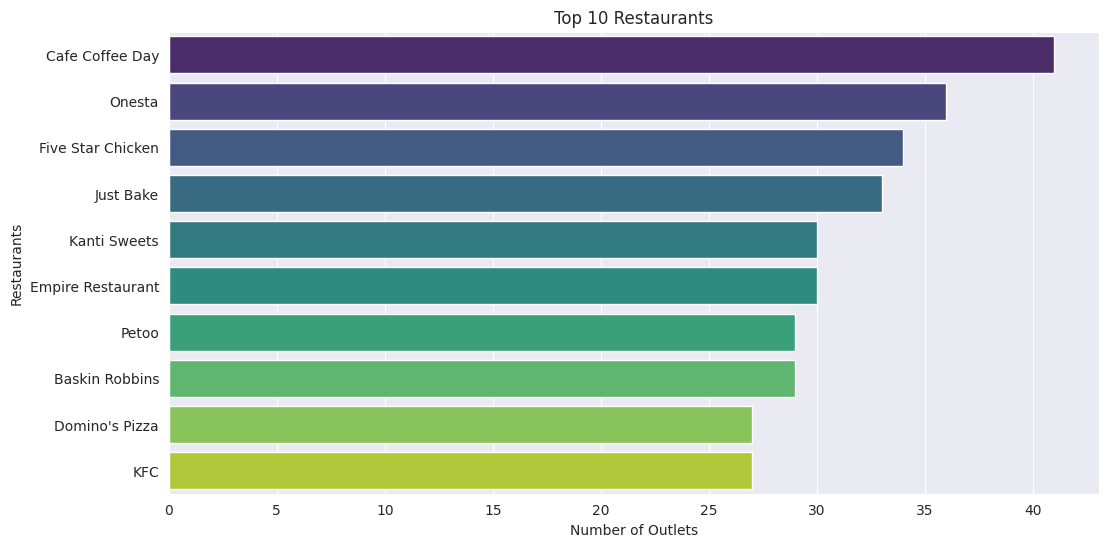

In [ ]:
plt.figure(figsize=(12,6))
sns.set_style('darkgrid')
ch=zomato['name'].value_counts()[:10]
sns.barplot(x=ch,y=ch.index,hue=ch.index,palette='viridis')
plt.title('Top 10 Restaurants')
plt.xlabel('Number of Outlets')
plt.ylabel('Restaurants')

In [ ]:
zomato

,address,name,online_order,book_table,rating,votes,location,restraunt_type,cuisines,cost,reviews_list,menu_item,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48840,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
48841,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,[],[],Pubs and bars,Whitefield
48842,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
48843,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


**Restraunts delivering online or not**

/tmp/ipykernel_28921/2159246139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(zomato['online_order'],palette='dark:salmon_r')


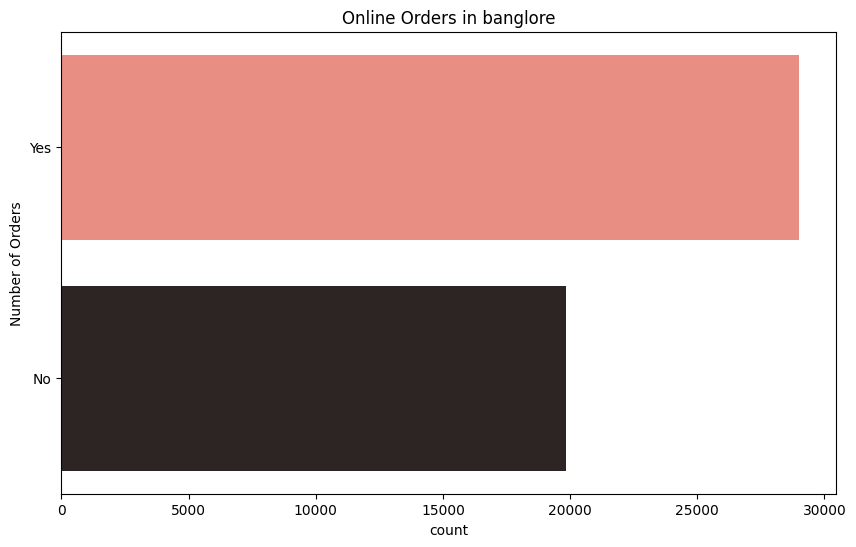

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(zomato['online_order'],palette='dark:salmon_r')
plt.title('Online Orders in banglore')
plt.ylabel('Number of Orders')
plt.show()

**Restraunts allowing advanced table booking or not**

/tmp/ipykernel_28921/2065860843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(zomato['book_table'],palette='dark:salmon_r')


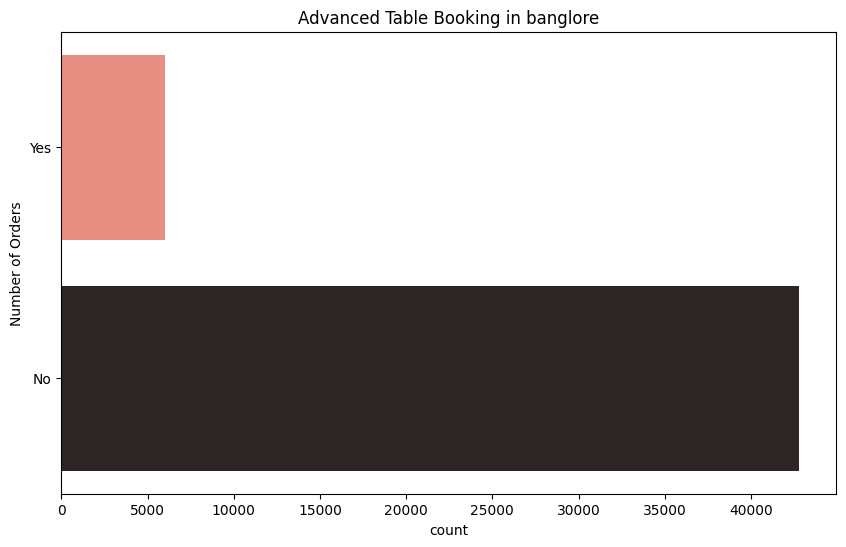

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(zomato['book_table'],palette='dark:salmon_r')
plt.title('Advanced Table Booking in banglore')
plt.ylabel('Number of Orders')
plt.show()

**Table booking allowed vs rating**

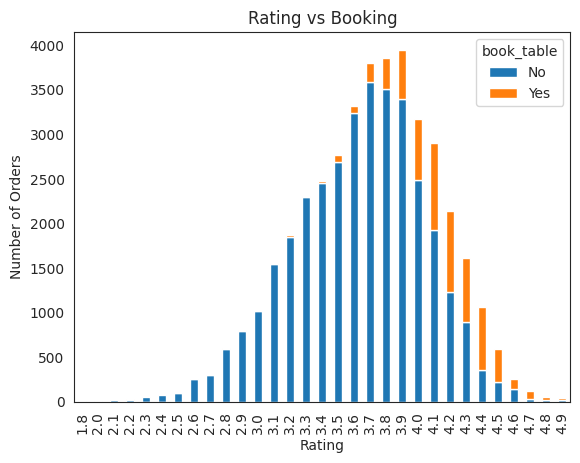

In [ ]:
sns.set_style('white')
y=pd.crosstab(zomato['rating'],zomato['book_table'])
y.plot(kind='bar',stacked=True)
plt.title('Rating vs Booking')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

**BEST LOCATIONS**

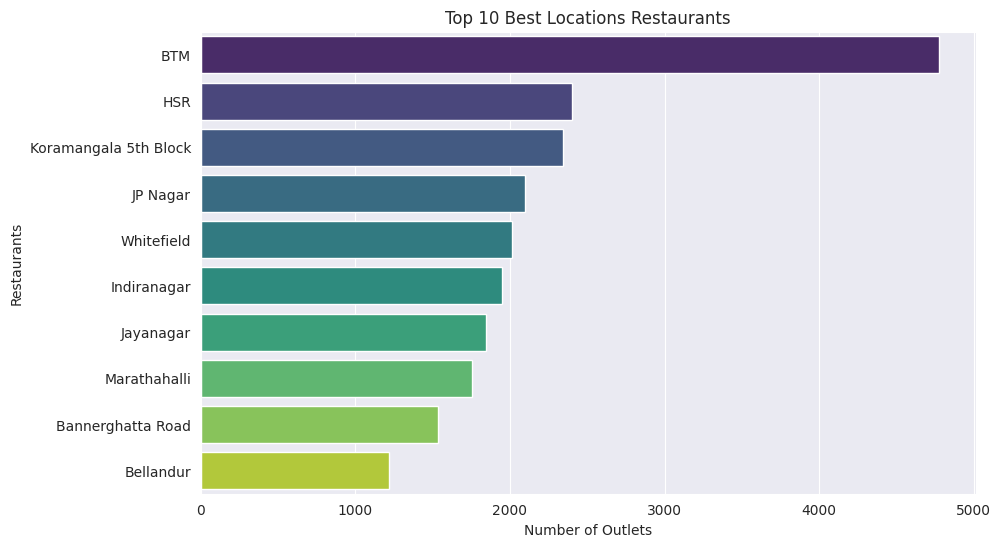

In [ ]:
plt.figure(figsize=(10,6))
sns.set_style('darkgrid')
ch=zomato['location'].value_counts()[:10]
sns.barplot(x=ch,y=ch.index,hue=ch.index,palette='viridis')
plt.title('Top 10 Best Locations Restaurants')
plt.xlabel('Number of Outlets')
plt.ylabel('Restaurants')
plt.show()

**Location Vs Rating**

/tmp/ipykernel_28921/3203314909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location',y='rating',data=zomato,palette='magma')


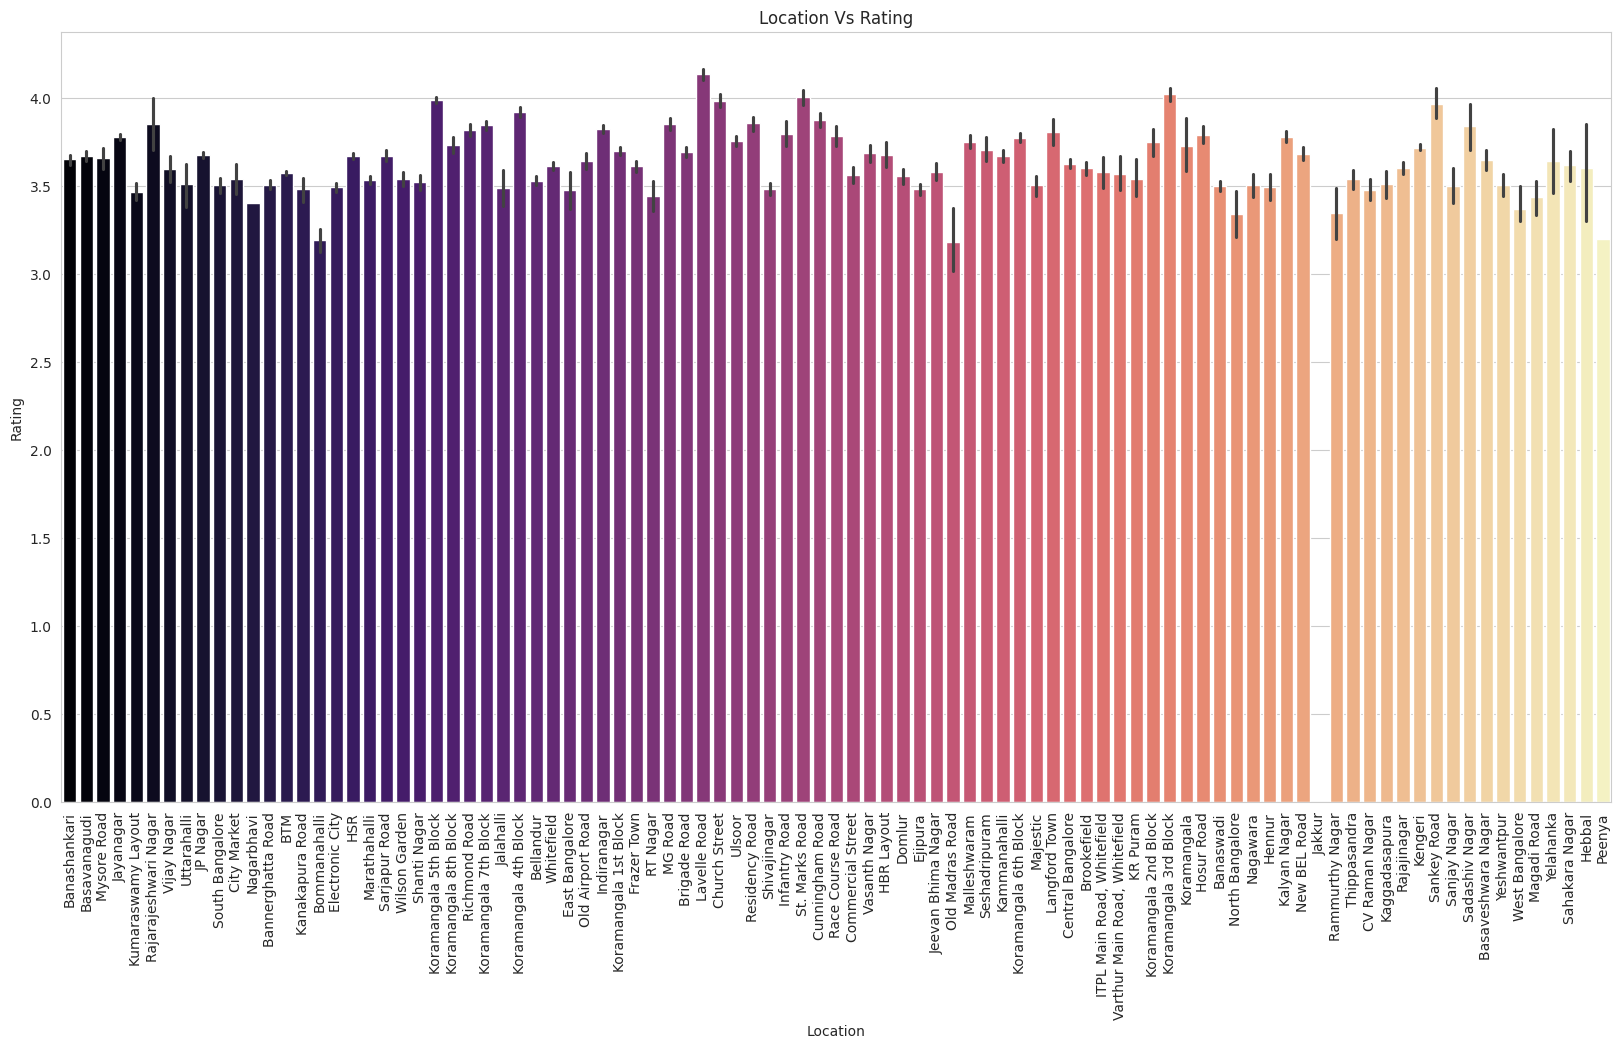

In [ ]:
plt.figure(figsize=(20,10))
sns.set_style('whitegrid')
sns.barplot(x='location',y='rating',data=zomato,palette='magma')
plt.title("Location Vs Rating")
plt.xlabel('Location')
plt.xticks(rotation=90)
plt.ylabel('Rating')
plt.show()
